# Passive vs Active Learning with a one-oversized-hidden-layer network

Three training approaches are compared on 3 classification and 3 function-approximation problems:

| Name | What it does |
|---|---|
| **passive** | Plain SGD on the whole training set every epoch. |
| **sasla** | *Selective* learning (Engelbrecht 2001). Starts on all patterns. After every epoch the sensitivity of the network output to the inputs is computed for **all** candidate patterns, and only patterns with informativeness above `(1 - beta) * mean` are used in the next epoch. |
| **alus** | *Incremental* uncertainty sampling. Starts on a small random subset, and every few epochs adds the patterns the current model is most uncertain about (entropy for classification, committee variance for regression) until a label budget is used up. |

The three methods use the same network, the same starting weights and the same folds, so the comparison is paired.

In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, r2_score
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

# ---------------- experiment settings ----------------
SEED       = 0
MAX_ROWS   = 1500     # big datasets are cut down using random sampling to this many rows so the code runs in reasonable time
EPOCHS     = 60       # every method trains for the same number of epochs
BATCH      = 32       # mini-batch size for SGD
MOMENTUM   = 0.9
N_FOLDS    = 10       # cross-validation folds 
EVAL_EVERY = 5        # test the network every 5 epochs for plotting learning curves

# ALUS settings
ALUS_START  = 0.10    # start with 10% of the training patterns
ALUS_BUDGET = 0.50    # never use more than 50% of the training patterns
ALUS_ROUND  = 5       # query new patterns every 5 epochs

# grids used when tuning the control parameters
LRS       = [0.01, 0.005, 0.001]   # learning rates
WDS       = [0, 1e-4, 1e-3, 1e-2]   # weight-decay (L2 penalty) coefficients
BETAS     = [0.3, 0.6, 0.9]          # SASLA selection constant beta
ADD_FRACS = [0.05, 0.10]             # ALUS: fraction of the training set added per query

FIG_DIR = "./figures"   # saved alongside the notebook
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Data

In [4]:

from ucimlrepo import fetch_ucirepo
from sklearn.datasets import fetch_california_housing

# ---- classification problems ----
letter = fetch_ucirepo(id=54)      # ISOLET (26 classes) - balanced - speech letter recognition
bank   = fetch_ucirepo(id=222)     # Bank marketing (2 classes, imbalanced)
bankrupt = fetch_ucirepo(id=572)   # Taiwanese company Bankruptcy prediction (2 classes, imbalanced)

# ---- function approximation problems ----
crime   = fetch_ucirepo(id=183) # violent crime per population prediciton
football  = pd.read_csv("FootballSalaryRegression.csv")  
insurance = pd.read_csv("insurance.csv")

# missing values are encoded as "?", convert them to np.nan and cast numerical columns
crime_X = crime.data.features.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")

# Football: remove the target and all columns that leak target info
target = "Annual EUR"
football = football.dropna(subset=[target])
performance_cols = [
    'Pos_x', 'Age_x', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 
    'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 
    'PrgC', 'PrgP', 'PrgR', 'Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1', 'G+A-PK', 
    'xG.1', 'xAG.1', 'xG+xAG', 'npxG.1', 'npxG+xAG.1'
]
football_X = football[performance_cols]

# 'duration' is only known after the call, so it would leak the answer.
bank_X = bank.data.features.drop(columns=["duration"])

raw = {   # name: (inputs, targets, task)
    "Letter prediction":     (letter.data.features,   letter.data.targets.values.ravel(),   "classification"),
    "Bank Marketing":        (bank_X,                 bank.data.targets.values.ravel(),     "classification"),
    "Bankruptcy prediction": (bankrupt.data.features, bankrupt.data.targets.values.ravel(), "classification"),
    "Crime":                 (crime_X,                crime.data.targets.values.ravel(),    "regression"),
    "Football Salary":       (football_X,             football[target].values,              "regression"),
    "Medical Insurance":     (insurance.drop(columns=["charges"]), insurance["charges"].values, "regression"),
}

In [5]:
football_X

,Pos_x,Age_x,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,...,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,xG.1,xAG.1,xG+xAG,npxG.1,npxG+xAG.1
0,"FW,MF",37,28.0,26.0,2421.0,26.9,29.0,16.0,45.0,28.0,...,1.08,0.59,1.67,1.04,1.64,0.83,0.52,1.35,0.78,1.30
1,FW,32,10.0,9.0,803.0,8.9,9.0,2.0,11.0,9.0,...,1.01,0.22,1.23,1.01,1.23,0.59,0.33,0.93,0.59,0.93
2,MF,36,33.0,32.0,2867.0,31.9,0.0,8.0,8.0,0.0,...,0.00,0.25,0.25,0.00,0.25,0.01,0.20,0.21,0.01,0.21
3,"FW,MF",30,31.0,31.0,2706.0,30.1,6.0,4.0,10.0,3.0,...,0.20,0.13,0.33,0.10,0.23,0.30,0.10,0.40,0.22,0.32
4,FW,29,27.0,22.0,1824.0,20.3,9.0,8.0,17.0,7.0,...,0.44,0.39,0.84,0.35,0.74,0.49,0.22,0.72,0.42,0.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2826,MF,19,1.0,0.0,23.0,0.3,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2827,RB,24,2.0,1.0,99.0,1.1,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2828,FW,19,1.0,0.0,14.0,0.2,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2829,LB,21,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [6]:
# Cut big datasets down to MAX_ROWS and turn class names into 0..K-1
rng = np.random.RandomState(SEED)
datasets = {}
for name, (X, y, task) in raw.items():
    X = X.reset_index(drop=True)
    y = np.asarray(y)
    if len(X) > MAX_ROWS:
        keep = rng.choice(len(X), MAX_ROWS, replace=False)
        X, y = X.iloc[keep].reset_index(drop=True), y[keep]
    y = LabelEncoder().fit_transform(y) if task == "classification" else y.astype(np.float32)
    datasets[name] = (X, y, task)
    print(f"{name:18s} {task:15s} rows={len(X):5d}  features={X.shape[1]}")

Letter prediction  classification  rows= 1500  features=617
Bank Marketing     classification  rows= 1500  features=15
Bankruptcy prediction classification  rows= 1500  features=95
Crime              regression      rows= 1500  features=127
Football Salary    regression      rows= 1500  features=31
Medical Insurance  regression      rows= 1338  features=6


## 2. Preprocessing, network and helper functions 

* Numeric inputs: missing values -> median, then standardised. Categorical inputs: missing -> most frequent, then one-hot. Everything is **fitted on the training part of each fold only**, so no information leaks from the test fold.
* Regression targets are standardised with the training mean/std.
* One hidden layer with `2 * inputs` units (max 1234), which is 2*617 whichis the number of features in the biggest dataset. Overfitting is controlled with **weight decay**; its coefficient is tuned per dataset.
* Classification uses softmax + cross-entropy, regression uses a linear output + MSE.

In [8]:
def build_preprocessor(X):
    numeric = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical = X.select_dtypes(exclude=[np.number]).columns.tolist()
    return ColumnTransformer([
        ("num", Pipeline([("fill", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric),
        ("cat", Pipeline([("fill", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical),
    ])


def prepare(X_train, y_train, X_test, y_test, task):
    # Fit the preprocessing on the training rows only and return everything as tensors.
    prep = build_preprocessor(X_train)
    data = {"task": task,
            "Xtr": torch.tensor(prep.fit_transform(X_train), dtype=torch.float32),
            "Xte": torch.tensor(prep.transform(X_test), dtype=torch.float32)}
    if task == "classification":
        data["ytr"] = torch.tensor(y_train, dtype=torch.long)
        data["yte"] = torch.tensor(y_test, dtype=torch.long)
        data["n_out"] = int(max(y_train.max(), y_test.max())) + 1
    else:
        mean, std = y_train.mean(), y_train.std()
        data["ytr"] = torch.tensor((y_train - mean) / std, dtype=torch.float32).reshape(-1, 1)
        data["yte"] = torch.tensor((y_test - mean) / std, dtype=torch.float32).reshape(-1, 1)
        data["n_out"] = 1
    return data


def make_model(n_inputs, n_outputs):
    hidden = min(2 * n_inputs, 1234)          # over-sized on purpose
    return nn.Sequential(nn.Linear(n_inputs, hidden), nn.Tanh(), nn.Linear(hidden, n_outputs))


def make_loss(task):
    return nn.CrossEntropyLoss() if task == "classification" else nn.MSELoss()


def run_epoch(model, opt, loss_fn, X, y, idx):
    # One epoch of mini-batch SGD over the patterns listed in idx.
    order = np.random.permutation(idx)
    for start in range(0, len(order), BATCH):
        batch = order[start:start + BATCH]
        opt.zero_grad()
        loss = loss_fn(model(X[batch]), y[batch])
        loss.backward()
        
        # gradient clipping here to prevent NaNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        opt.step()


def evaluate(model, X, y, task):
    # Returns (main metric, second metric). Main metric: higher is better.
    with torch.no_grad():
        out = model(X)
    if task == "classification":
        pred, true = out.argmax(dim=1).numpy(), y.numpy()
        return f1_score(true, pred, average="macro"), accuracy_score(true, pred)
    pred, true = out.numpy().ravel(), y.numpy().ravel()
    return r2_score(true, pred), float(np.mean((pred - true) ** 2))

## 3. The two active learning criteria

**SASLA informativeness.** For every pattern, the sensitivity of output *k* to the inputs is `S_k = sum_i |d o_k / d z_i|` (sum-norm, eq. 5 in the originalSASLA paper) and the informativeness is the largest over the outputs, `Phi = max_k S_k` (eq. 2). Patterns close to a decision boundary have a large `Phi`. For classification the outputs are the softmax probabilities; for regression it is the raw output.

**ALUS uncertainty.** Classification: entropy of the predicted class probabilities ( eq. 1 of the ALUS paper). The ALUS paper is for  classification only, so for regression I use the variance of a small committee of networks trained on bootstrap samples of the labelled patterns.

In [10]:
def informativeness(model, X, task):
    # SASLA: Phi = max over outputs of the sum over inputs of |d output / d input|
    X = X.clone().requires_grad_(True)
    out = model(X)
    if task == "classification":
        out = torch.softmax(out, dim=1)
    phi = torch.zeros(len(X))
    for k in range(out.shape[1]):
        grad = torch.autograd.grad(out[:, k].sum(), X, retain_graph=True)[0]
        phi = torch.maximum(phi, grad.abs().sum(dim=1))
    return phi.detach().numpy()


def class_entropy(model, X):
    # ALUS for classification
    with torch.no_grad():
        p = torch.softmax(model(X), dim=1).clamp_min(1e-7)
    return -(p * p.log()).sum(dim=1).numpy()


def committee_variance(X_lab, y_lab, X_pool, p, n_models=5, epochs=10):
    # ALUS for regression: disagreement of a few networks trained on bootstrap samples
    preds = []
    for _ in range(n_models):
        boot = np.random.choice(len(X_lab), len(X_lab), replace=True)
        net = make_model(X_lab.shape[1], 1)
        opt = torch.optim.SGD(net.parameters(), lr=p["lr"], momentum=MOMENTUM, weight_decay=p["wd"])
        for _ in range(epochs):
            run_epoch(net, opt, nn.MSELoss(), X_lab, y_lab, boot)
        with torch.no_grad():
            preds.append(net(X_pool))
    return torch.stack(preds).var(dim=0).squeeze(1).numpy()

## 4. One training function shared byall methods

The only thing that differs between the methods is *which patterns are used in the next epoch* (`idx`). The same seed gives every method the same starting weights.

In [12]:
def train_model(method, data, p, seed):
    # method: "passive", "sasla", "alus" or "random". "random" follows ALUS's exact schedule (same start size, same growth, same budget) but adds random patterns instead of the most uncertain ones.
    np.random.seed(seed)
    task, Xtr, ytr = data["task"], data["Xtr"], data["ytr"]
    n = len(Xtr)

    model = make_model(Xtr.shape[1], data["n_out"])
    opt = torch.optim.SGD(model.parameters(), lr=p["lr"], momentum=MOMENTUM, weight_decay=p["wd"])
    loss_fn = make_loss(task)

    idx = np.arange(n)                                    # patterns used in the first epoch
    if method in ("alus", "random"):
        labeled = np.zeros(n, dtype=bool)
        labeled[np.random.permutation(n)[:int(ALUS_START * n)]] = True
        idx = np.where(labeled)[0]

    presentations, history, subset_sizes = 0, [], []
    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        subset_sizes.append(len(idx))
        run_epoch(model, opt, loss_fn, Xtr, ytr, idx)
        presentations += len(idx)

        if method == "sasla":
            phi = informativeness(model, Xtr, task)
            idx = np.where(phi > (1 - p["beta"]) * phi.mean())[0]
            if len(idx) == 0:
                idx = np.arange(n)

        elif method in ("alus", "random") and epoch % ALUS_ROUND == 0:
            n_add = min(int(p["add_frac"] * n), int(ALUS_BUDGET * n) - int(labeled.sum()))
            if n_add > 0:
                pool = np.where(~labeled)[0]
                if method == "random":
                    chosen = np.random.choice(pool, n_add, replace=False)
                elif task == "classification":
                    scores = class_entropy(model, Xtr[pool])
                    chosen = pool[np.argsort(scores)[-n_add:]]
                else:
                    lab = np.where(labeled)[0]
                    scores = committee_variance(Xtr[lab], ytr[lab], Xtr[pool], p)
                    chosen = pool[np.argsort(scores)[-n_add:]]
                labeled[chosen] = True                     # most uncertain (or random if method random)
                idx = np.where(labeled)[0]

        if epoch % EVAL_EVERY == 0:
            history.append((presentations, evaluate(model, data["Xte"], data["yte"], task)[0]))

    score, second = evaluate(model, data["Xte"], data["yte"], task)
    return {"score": score, "second": second,
            "cost": presentations / (EPOCHS * n),        # 1 = as many presentations as passive
            "time": time.time() - t0, "history": history, "subset_sizes": subset_sizes}

## 5. Tuning the control parameters

Tuning uses a separate 30% slice of every dataset that is **not** used in the cross-validation, so the test folds never influence the chosen values. Inside that slice: 70% to train, 30% to validate, average of two seeds.

1. `lr` and weight-decay coefficient `wd` are found with passive learning and then shared by all three methods, so every method gets the same base SGD settings. The penalty is problem dependent, which is why it is searched per dataset.
2. `beta` for SASLA, then `add_frac` for ALUS, are tuned on top of that.

In [14]:
def score_of(method, data, p, seeds=(1, 2)):
    return np.mean([train_model(method, data, p, s)["score"] for s in seeds])


def tune(X, y, task):
    stratify = y if task == "classification" else None
    Xa, Xv, ya, yv = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=stratify)
    data = prepare(Xa, ya, Xv, yv, task)

    p = {"lr": 0.01, "wd": 0.0, "beta": 0.9, "add_frac": 0.05}
    grid = [(lr, wd) for lr in LRS for wd in WDS]
    p["lr"], p["wd"] = max(grid, key=lambda g: score_of("passive", data, {**p, "lr": g[0], "wd": g[1]}))
    p["beta"] = max(BETAS, key=lambda b: score_of("sasla", data, {**p, "beta": b}))
    p["add_frac"] = max(ADD_FRACS, key=lambda a: score_of("alus", data, {**p, "add_frac": a}))
    return p

## 6. Running all methods

For each dataset, every fold is one paired simulation: the three methods see the same train/test split and start from the same initial weights.

In [16]:
METHODS = ["passive", "sasla", "alus", "random"]  
results, best_params = {}, {}

for name, (X, y, task) in datasets.items():
    print(f"\n=== {name} ===")
    stratify = y if task == "classification" else None
    X_tune, X_cv, y_tune, y_cv = train_test_split(X, y, test_size=0.7, random_state=SEED, stratify=stratify)
    X_cv = X_cv.reset_index(drop=True)

    best_params[name] = tune(X_tune.reset_index(drop=True), y_tune, task)
    print("chosen parameters:", best_params[name])

    Splitter = StratifiedKFold if task == "classification" else KFold
    folds = Splitter(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(X_cv, y_cv)

    runs = {m: [] for m in METHODS}
    for fold, (tr, te) in enumerate(folds):
        data = prepare(X_cv.iloc[tr], y_cv[tr], X_cv.iloc[te], y_cv[te], task)
        for m in METHODS:
            runs[m].append(train_model(m, data, best_params[name], seed=fold))
        print(f"  fold {fold + 1}/{N_FOLDS} done")
    results[name] = runs


=== Letter prediction ===
chosen parameters: {'lr': 0.005, 'wd': 0.0001, 'beta': 0.9, 'add_frac': 0.05}
  fold 1/10 done
  fold 2/10 done
  fold 3/10 done
  fold 4/10 done
  fold 5/10 done
  fold 6/10 done
  fold 7/10 done
  fold 8/10 done
  fold 9/10 done
  fold 10/10 done

=== Bank Marketing ===
chosen parameters: {'lr': 0.01, 'wd': 0, 'beta': 0.6, 'add_frac': 0.1}
  fold 1/10 done
  fold 2/10 done
  fold 3/10 done
  fold 4/10 done
  fold 5/10 done
  fold 6/10 done
  fold 7/10 done
  fold 8/10 done
  fold 9/10 done
  fold 10/10 done

=== Bankruptcy prediction ===
chosen parameters: {'lr': 0.01, 'wd': 0.0001, 'beta': 0.6, 'add_frac': 0.05}
  fold 1/10 done
  fold 2/10 done
  fold 3/10 done
  fold 4/10 done
  fold 5/10 done
  fold 6/10 done
  fold 7/10 done
  fold 8/10 done
  fold 9/10 done
  fold 10/10 done

=== Crime ===
chosen parameters: {'lr': 0.001, 'wd': 0.01, 'beta': 0.6, 'add_frac': 0.05}
  fold 1/10 done
  fold 2/10 done
  fold 3/10 done
  fold 4/10 done
  fold 5/10 done
  f

## 7. Results

In [18]:
# Mean +- std over the folds. cost = training-pattern presentations relative to passive (=1).
rows = []
for name, runs in results.items():
    task = datasets[name][2]
    main, second = ("F1 (macro)", "accuracy") if task == "classification" else ("R2", "MSE (scaled)")
    for m in METHODS:
        r = runs[m]
        s = [x["score"] for x in r]
        rows.append({"dataset": name, "method": m, "metric": main,
                     "mean": round(np.mean(s), 4), "std": round(np.std(s), 4),
                     second: round(np.mean([x["second"] for x in r]), 4),
                     "cost": round(np.mean([x["cost"] for x in r]), 2),
                     "time (s)": round(np.mean([x["time"] for x in r]), 1)})
summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(FIG_DIR, "..", "summary_table.csv"), index=False)
with open(os.path.join(FIG_DIR, "..", "summary_table.tex"), "w") as f:
    f.write(summary.to_latex(index=False, float_format="%.4f",
                             caption="Score, cost and time by method and dataset.",
                             label="tab:summary"))
summary

,dataset,method,metric,mean,std,accuracy,cost,time (s),MSE (scaled)
0,Letter prediction,passive,F1 (macro),0.9242,0.0284,0.9238,1.00,4.7,NaN
1,Letter prediction,sasla,F1 (macro),0.9280,0.0267,0.9276,0.87,13.5,NaN
2,Letter prediction,alus,F1 (macro),0.9237,0.0305,0.9257,0.35,1.6,NaN
3,Letter prediction,random,F1 (macro),0.8892,0.0308,0.8905,0.35,1.7,NaN
4,Bank Marketing,passive,F1 (macro),0.6339,0.0761,0.9086,1.00,1.4,NaN
5,Bank Marketing,sasla,F1 (macro),0.6325,0.0985,0.9057,0.80,1.2,NaN
6,Bank Marketing,alus,F1 (macro),0.6194,0.0888,0.9010,0.42,0.6,NaN
7,Bank Marketing,random,F1 (macro),0.6006,0.0754,0.9038,0.42,0.6,NaN
8,Bankruptcy prediction,passive,F1 (macro),0.6571,0.1031,0.9590,1.00,1.6,NaN
9,Bankruptcy prediction,sasla,F1 (macro),0.6255,0.0805,0.9533,0.34,0.7,NaN


In [19]:
# Paired Wilcoxon signed-rank test on the fold scores, per dataset, plus a paired effect size (Cohen\'s d) so a "not significant" result can be told apart from "no real difference" versus "underpowered test with only 10 folds".
def wilcoxon_p(a, b):
    try:
        return stats.wilcoxon(a, b).pvalue
    except ValueError:          # all differences are zero
        return 1.0

def cohens_d(a, b):
    diff = np.array(a) - np.array(b)
    sd = diff.std(ddof=1)
    return float(diff.mean() / sd) if sd > 0 else 0.0

pairs = [("sasla", "passive"), ("alus", "passive"), ("random", "passive"),
         ("alus", "random"), ("sasla", "alus")]
rows = []
for name, runs in results.items():
    for a, b in pairs:
        sa = [x["score"] for x in runs[a]]
        sb = [x["score"] for x in runs[b]]
        p_val = wilcoxon_p(sa, sb)
        rows.append({"dataset": name, "comparison": f"{a} vs {b}",
                     "mean diff (first - second)": round(np.mean(sa) - np.mean(sb), 4),
                     "cohen\'s d": round(cohens_d(sa, sb), 2),
                     "p-value": round(p_val, 4), "significant": p_val < 0.05 / len(pairs)})
sig_table = pd.DataFrame(rows)
sig_table.to_csv(os.path.join(FIG_DIR, "..", "significance_table.csv"), index=False)
with open(os.path.join(FIG_DIR, "..", "significance_table.tex"), "w") as f:
    f.write(sig_table.to_latex(index=False, float_format="%.4f",
                               caption="Pairwise Wilcoxon tests and effect sizes.",
                               label="tab:significance"))
sig_table

,dataset,comparison,mean diff (first - second),cohen's d,p-value,significant
0,Letter prediction,sasla vs passive,0.0038,0.30,0.2135,False
1,Letter prediction,alus vs passive,-0.0005,-0.03,0.9219,False
2,Letter prediction,random vs passive,-0.0350,-1.05,0.0195,False
3,Letter prediction,alus vs random,0.0345,1.23,0.0020,True
4,Letter prediction,sasla vs alus,0.0043,0.21,0.8590,False
5,Bank Marketing,sasla vs passive,-0.0014,-0.03,0.7532,False
6,Bank Marketing,alus vs passive,-0.0145,-0.24,0.3270,False
7,Bank Marketing,random vs passive,-0.0333,-0.44,0.3139,False
8,Bank Marketing,alus vs random,0.0188,0.19,0.4413,False
9,Bank Marketing,sasla vs alus,0.0131,0.20,0.6002,False


In [20]:
# Overall picture across the 6 problems: rank the methods per dataset (1 = best), then Friedman test.
mean_scores = pd.DataFrame({name: {m: np.mean([x["score"] for x in runs[m]]) for m in METHODS}
                            for name, runs in results.items()}).T
ranks = mean_scores.rank(axis=1, ascending=False)
print("Average rank (lower is better):")
print(ranks.mean().round(2).to_string())
print()
print("Friedman test:", stats.friedmanchisquare(*[mean_scores[m] for m in METHODS]))
print()
print("Average cost relative to passive:")
print(summary.groupby("method")["cost"].mean().round(2).to_string())

Average rank (lower is better):
passive    1.33
sasla      1.67
alus       3.00
random     4.00

Friedman test: FriedmanchisquareResult(statistic=16.400000000000006, pvalue=0.0009387420550450392)

Average cost relative to passive:
method
alus       0.37
passive    1.00
random     0.37
sasla      0.84


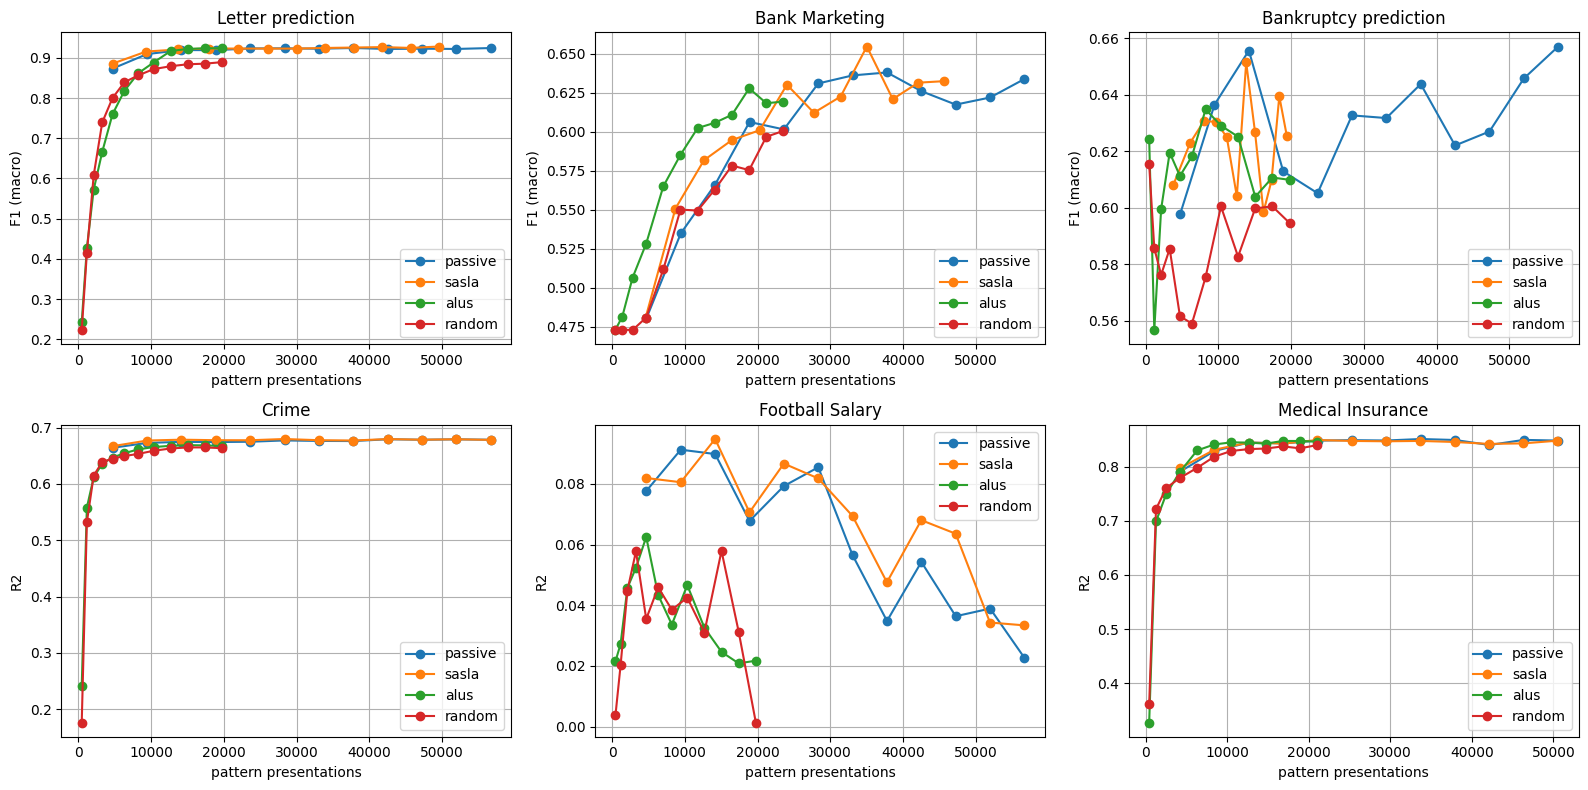

In [21]:
# Learning curves: test score against the number of pattern presentations (training cost)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (name, runs) in zip(axes.ravel(), results.items()):
    for m in METHODS:
        h = np.array([r["history"] for r in runs[m]])       # folds x evaluations x (presentations, score)
        ax.plot(h[:, :, 0].mean(axis=0), h[:, :, 1].mean(axis=0), marker="o", label=m)
    ax.set_title(name)
    ax.set_xlabel("pattern presentations")
    ax.set_ylabel("F1 (macro)" if datasets[name][2] == "classification" else "R2")
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "learning_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

## 8. Diagnostics: efficiency, selection behaviour and the random check


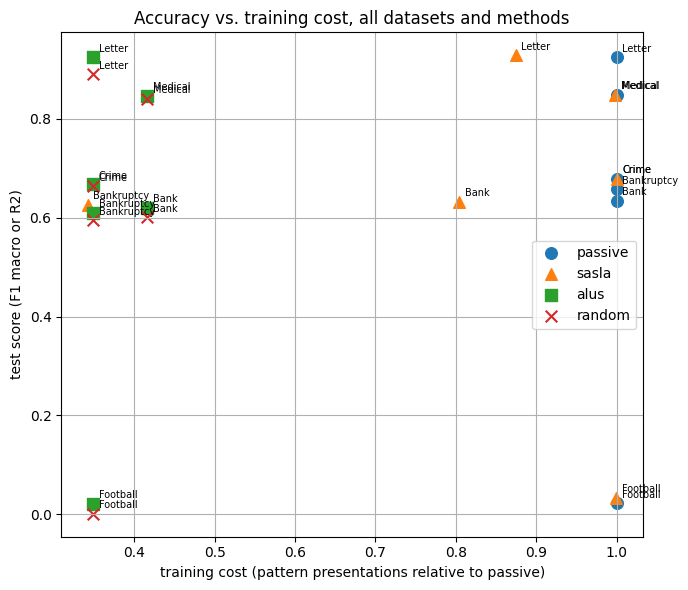

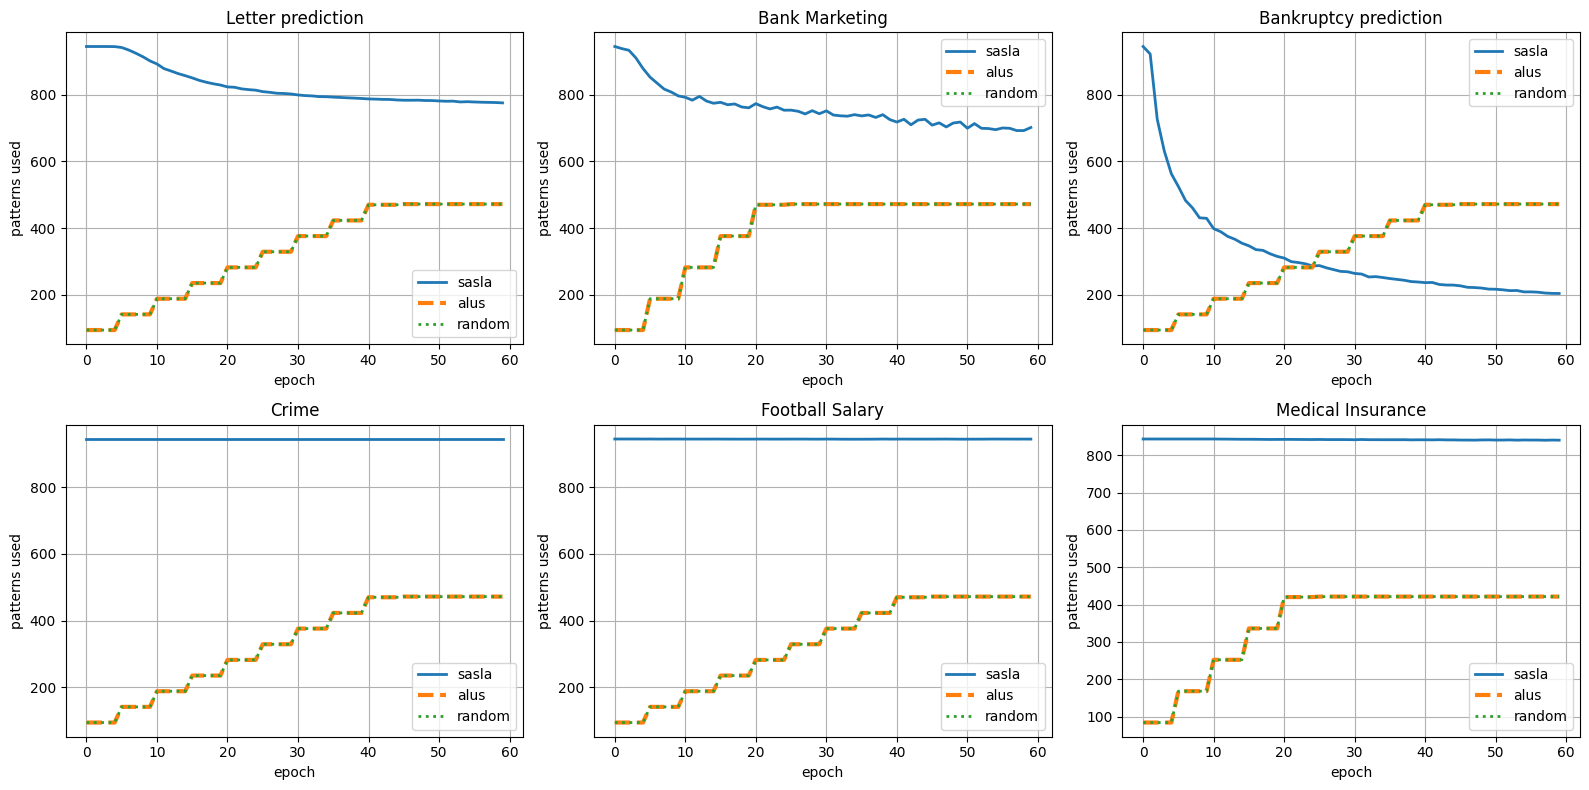

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
markers = {"passive": "o", "sasla": "^", "alus": "s", "random": "x"}
seen = set()
for name, runs in results.items():
    for m in METHODS:
        s = [x["score"] for x in runs[m]]
        c = [x["cost"] for x in runs[m]]
        ax.scatter(np.mean(c), np.mean(s), marker=markers[m], s=70, color=f"C{METHODS.index(m)}",
                   label=m if m not in seen else None)
        seen.add(m)
        ax.annotate(name.split()[0], (np.mean(c), np.mean(s)), fontsize=7,
                    xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("training cost (pattern presentations relative to passive)")
ax.set_ylabel("test score (F1 macro or R2)")
ax.set_title("Accuracy vs. training cost, all datasets and methods")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "efficiency_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
styles = {"sasla": dict(linestyle="-", linewidth=2),
          "alus": dict(linestyle="--", linewidth=3),
          "random": dict(linestyle=":", linewidth=2)}
for ax, (name, runs) in zip(axes.ravel(), results.items()):
    for m in ["sasla", "alus", "random"]:
        sizes = np.array([r["subset_sizes"] for r in runs[m]])
        ax.plot(sizes.mean(axis=0), label=m, **styles[m])
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("patterns used")
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "subset_size_trajectory.png"), dpi=300, bbox_inches="tight")
plt.show()

## 9. Bar charts: performance and cost by training strategy


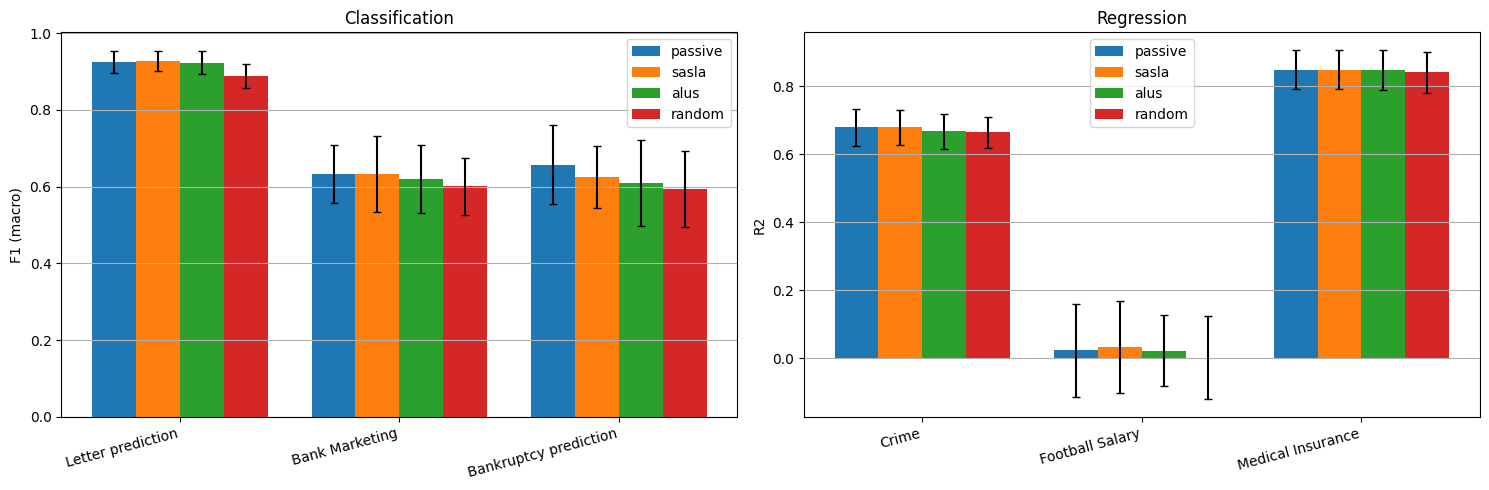

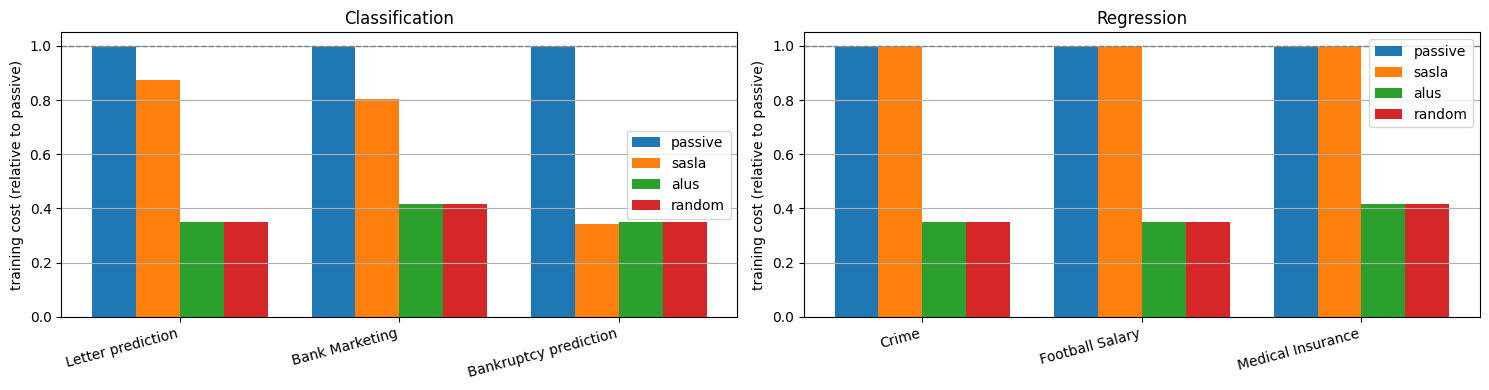

In [26]:

clf_names = [n for n in results if datasets[n][2] == "classification"]
reg_names = [n for n in results if datasets[n][2] == "regression"]
colors = {"passive": "C0", "sasla": "C1", "alus": "C2", "random": "C3"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for ax, names, ylabel, title in [(ax1, clf_names, "F1 (macro)", "Classification"),
                                  (ax2, reg_names, "R2", "Regression")]:
    x = np.arange(len(names))
    width = 0.8 / len(METHODS)
    for i, m in enumerate(METHODS):
        means = [np.mean([r["score"] for r in results[n][m]]) for n in names]
        stds = [np.std([r["score"] for r in results[n][m]]) for n in names]
        ax.bar(x + i * width, means, width, yerr=stds, capsize=3, label=m, color=colors[m])
    ax.set_xticks(x + width * (len(METHODS) - 1) / 2)
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "score_barchart.png"), dpi=300, bbox_inches="tight")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
for ax, names, title in [(ax1, clf_names, "Classification"), (ax2, reg_names, "Regression")]:
    x = np.arange(len(names))
    width = 0.8 / len(METHODS)
    for i, m in enumerate(METHODS):
        costs = [np.mean([r["cost"] for r in results[n][m]]) for n in names]
        ax.bar(x + i * width, costs, width, label=m, color=colors[m])
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=1)
    ax.set_xticks(x + width * (len(METHODS) - 1) / 2)
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylabel("training cost (relative to passive)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cost_barchart.png"), dpi=300, bbox_inches="tight")
plt.show()